In [1]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 36.9 MB/s  0:00:00


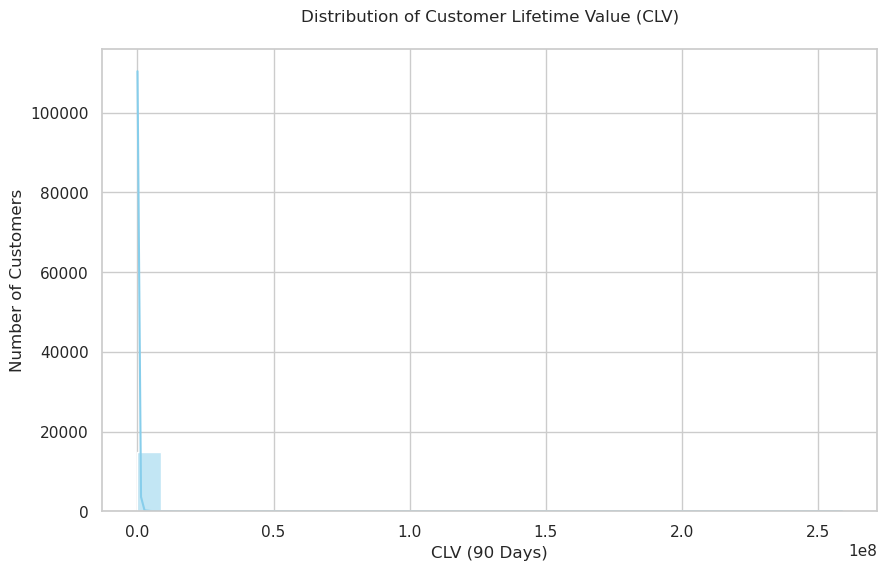

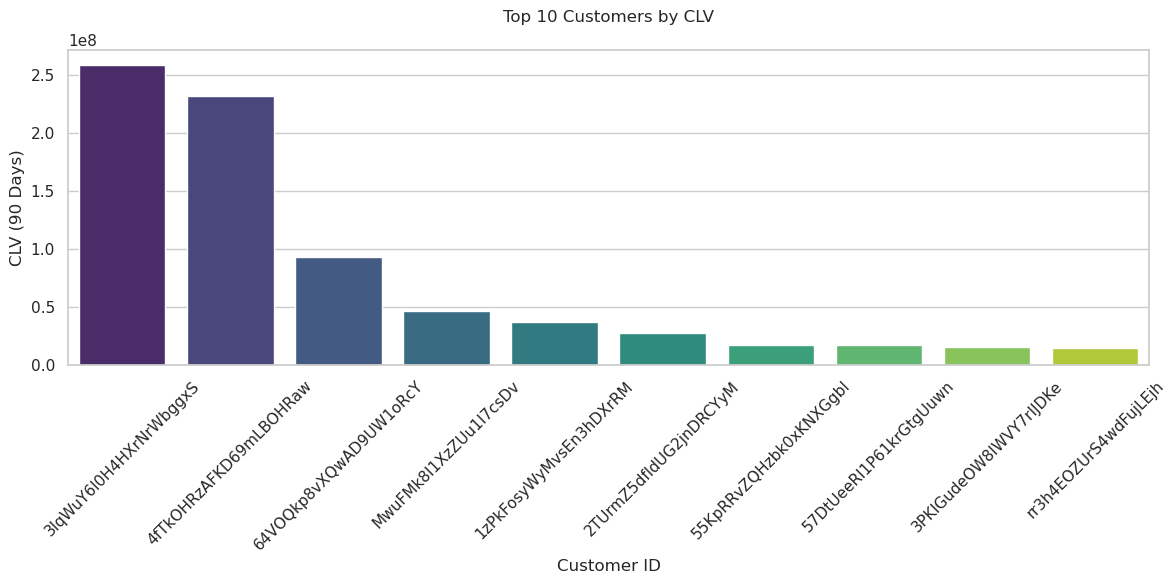

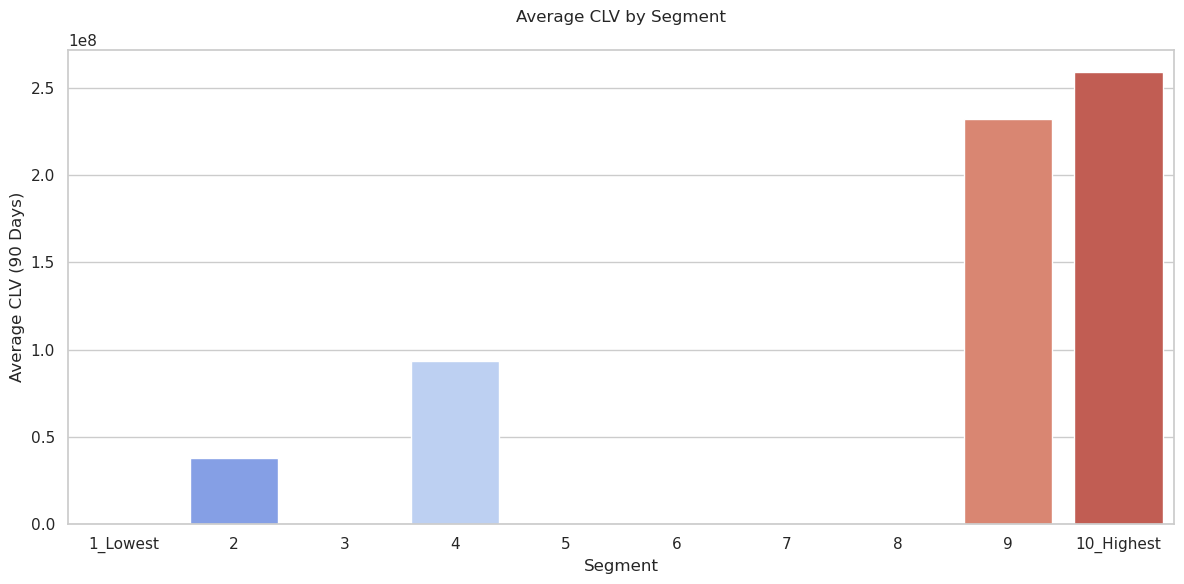

<Figure size 1000x800 with 0 Axes>

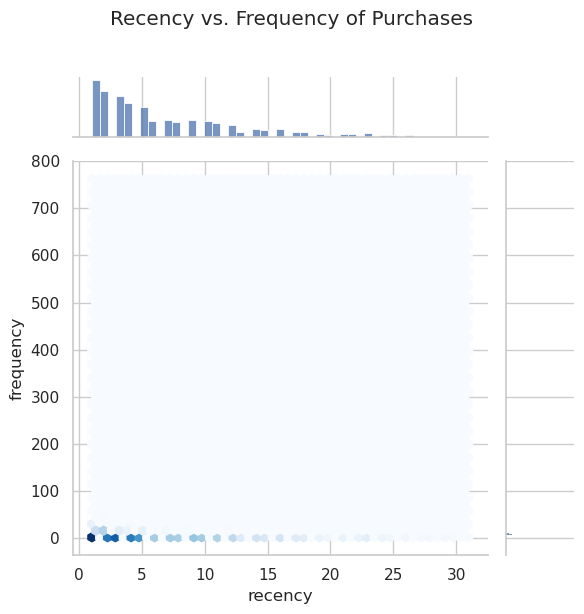

In [2]:
import pandas as pd
import numpy as np
from lifetimes import BetaGeoFitter, GammaGammaFitter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sales data - Order Delivered.csv', parse_dates=['order_date', 'dispatch_date'], low_memory=False)
df = df[(df['order_status'] == 'COMPLETED') & (df['gross_nmv'] > 0)]

#analysis date (day after last order)
analysis_date = df['order_date'].max() + timedelta(days=1)

#calculate 'T' (days since first purchase for each customer)
first_purchase = df.groupby('store_id')['order_date'].min().reset_index()
first_purchase.columns = ['store_id', 'first_purchase_date']
df = pd.merge(df, first_purchase, on='store_id', how='left')
df['T'] = (analysis_date - df['first_purchase_date']).dt.days  # Add 'T' column

#calculate RFM metrics
rfm = df.groupby('store_id').agg({
    'order_date': lambda x: (analysis_date - x.max()).days,  # Recency
    'order_number': 'count',                                # Frequency
    'gross_nmv': 'sum',                                    # Monetary (total)
    'T': 'first'                                           # Customer age (T)
}).rename(columns={
    'order_date': 'recency',
    'order_number': 'frequency',
    'gross_nmv': 'monetary_value'
})

rfm['monetary_value'] = rfm['monetary_value'] / rfm['frequency']  # Avg. order value
rfm = rfm[rfm['frequency'] > 1]  # Filter for BG/NBD model (requires frequency > 1)

#fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])
rfm['predicted_purchases_90'] = bgf.predict(90, rfm['frequency'], rfm['recency'], rfm['T'])

#fit Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.2)
ggf.fit(rfm['frequency'], rfm['monetary_value'])
rfm['clv_90'] = ggf.customer_lifetime_value(
    bgf, rfm['frequency'], rfm['recency'], rfm['T'], rfm['monetary_value'],
    time=3, freq='D'
)

#segment into 10 groups
rfm['clv_segment'] = pd.qcut(rfm['clv_90'], q=10, labels=False)
rfm['segment_name'] = pd.cut(rfm['clv_90'], bins=10, 
                            labels=['1_Lowest', '2', '3', '4', '5', '6', '7', '8', '9', '10_Highest'])

rfm.to_csv('customer_clv_results.csv')

#VISUALIZATIONS

sns.set_theme(style="whitegrid")  

# 1.CLV Distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm['clv_90'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Lifetime Value (CLV)', pad=20)
plt.xlabel('CLV (90 Days)')
plt.ylabel('Number of Customers')
plt.show()

# 2.Top 10 Highest-CLV Customers
top_customers = rfm.sort_values('clv_90', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_customers.index, y=top_customers['clv_90'], palette='viridis')
plt.title('Top 10 Customers by CLV', pad=20)
plt.xlabel('Customer ID')
plt.ylabel('CLV (90 Days)')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

# 3.Average CLV by Segment
segment_clv = rfm.groupby('segment_name')['clv_90'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='segment_name', y='clv_90', data=segment_clv, palette='coolwarm')
plt.title('Average CLV by Segment', pad=20)
plt.xlabel('Segment')
plt.ylabel('Average CLV (90 Days)')
plt.tight_layout()
plt.show()

# 4.Recency vs. Frequency Heatmap
plt.figure(figsize=(10, 8))
sns.jointplot(x='recency', y='frequency', data=rfm, kind='hex', cmap='Blues')
plt.suptitle('Recency vs. Frequency of Purchases', y=1.02)
plt.tight_layout()
plt.show()